# AI-Prognosis System: Mental Health Disorder Classification

## Project Overview
Building a neural network to classify mental health disorders using VGG16 architecture with tabular mental health symptom data.

## Data Preprocessing & Splitting

In [ ]:
# Install required packages
%pip install pandas numpy scikit-learn matplotlib seaborn tensorflow

# Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, models
from keras.applications import VGG16, ResNet50, MobileNetV2

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


## Step 1: Load and Explore the Dataset

In [23]:
# Load the dataset
df = pd.read_csv('weighted_oversampled_dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['Disorder'].value_counts())

Dataset Shape: (89291, 25)

First few rows:
  feeling.nervous panic breathing.rapidly sweating trouble.in.concentration  \
0              no    no                no       no                       no   
1              no    no                no       no                       no   
2              no    no                no       no                       no   
3              no    no                no       no                       no   
4              no    no                no       no                       no   

  having.trouble.in.sleeping having.trouble.with.work hopelessness anger  \
0                         no                       no           no    no   
1                         no                      yes          yes   yes   
2                         no                       no           no    no   
3                         no                       no           no    no   
4                         no                       no           no    no   

  over.react  ... weight

## Step 2: Data Preprocessing

In [9]:
# 2.1: Encode Categorical Features (Convert 'yes'/'no' to binary)
df_processed = df.copy()

# Convert yes/no to 1/0 for all features except the target
for col in df_processed.columns:
    if col != 'Disorder':
        df_processed[col] = (df_processed[col] == 'yes').astype(int)

print("After encoding yes/no to binary:")
print(df_processed.head())
print("\nData types:")
print(df_processed.dtypes)

After encoding yes/no to binary:
   feeling.nervous  panic  breathing.rapidly  sweating  \
0                0      0                  0         0   
1                0      0                  0         0   
2                0      0                  0         0   
3                0      0                  0         0   
4                0      0                  0         0   

   trouble.in.concentration  having.trouble.in.sleeping  \
0                         0                           0   
1                         0                           0   
2                         0                           0   
3                         0                           0   
4                         0                           0   

   having.trouble.with.work  hopelessness  anger  over.react  ...  \
0                         0             0      0           0  ...   
1                         1             1      1           1  ...   
2                         0             0      0        

In [24]:
# 2.2: Encode Target Variable (Disorder)
label_encoder = LabelEncoder()
df_processed['Disorder_Encoded'] = label_encoder.fit_transform(df_processed['Disorder'])

# Display the mapping
disorder_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nDisorder Label Mapping:")
print(disorder_mapping)

# Number of classes
num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")


Disorder Label Mapping:
{'Anxiety': np.int64(0), 'Depression': np.int64(1), 'Loneliness': np.int64(2), 'Normal': np.int64(3), 'Stress': np.int64(4)}

Number of classes: 5
Classes: ['Anxiety' 'Depression' 'Loneliness' 'Normal' 'Stress']


In [25]:
# 2.3: Prepare Features and Target
X = df_processed.drop(['Disorder', 'Disorder_Encoded'], axis=1)
y = df_processed['Disorder_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (89291, 24)
Target shape: (89291,)

Feature columns (24):
['feeling.nervous', 'panic', 'breathing.rapidly', 'sweating', 'trouble.in.concentration', 'having.trouble.in.sleeping', 'having.trouble.with.work', 'hopelessness', 'anger', 'over.react', 'change.in.eating', 'suicidal.thought', 'feeling.tired', 'close.friend', 'social.media.addiction', 'weight.gain', 'material.possessions', 'introvert', 'popping.up.stressful.memory', 'having.nightmares', 'avoids.people.or.activities', 'feeling.negative', 'trouble.concentrating', 'blamming.yourself']


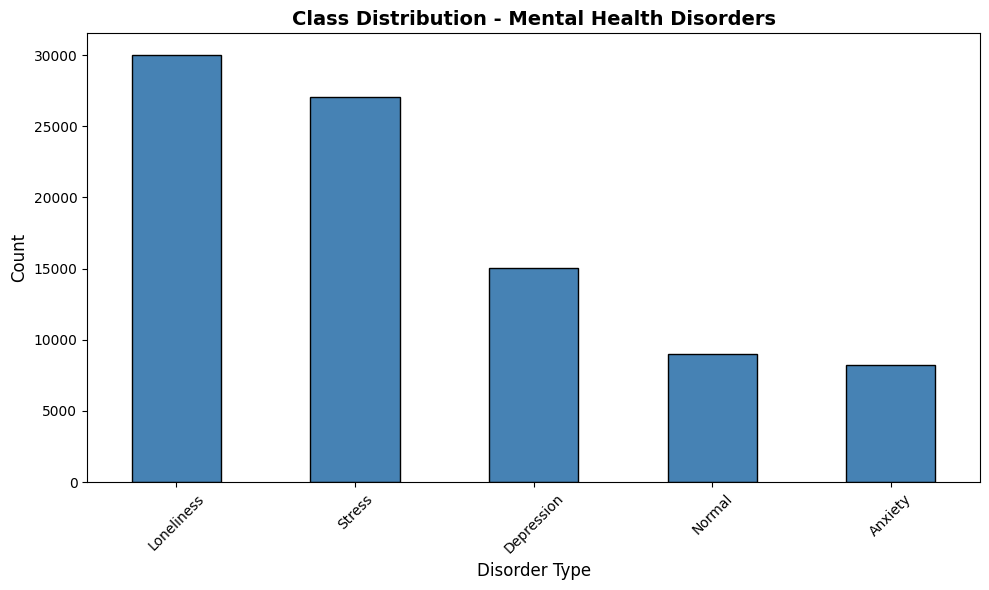


Class Distribution:
Disorder
Loneliness    30037
Stress        27033
Depression    15018
Normal         9011
Anxiety        8192
Name: count, dtype: int64


In [26]:
# 2.4: Visualize Class Distribution
plt.figure(figsize=(10, 6))
df['Disorder'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution - Mental Health Disorders', fontsize=14, fontweight='bold')
plt.xlabel('Disorder Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClass Distribution:")
print(df['Disorder'].value_counts())

In [27]:
# 2.5: Feature Scaling (Normalization)
# For neural networks, it's important to scale features to have mean~0 and std~1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier manipulation
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFeature Statistics After Scaling:")
print(f"Mean: {X_scaled.mean().mean():.6f} (should be ~0)")
print(f"Std Dev: {X_scaled.std().mean():.6f} (should be ~1)")
print("\nFirst few rows after scaling:")
print(X_scaled.head())


Feature Statistics After Scaling:
Mean: -0.000000 (should be ~0)
Std Dev: 1.000006 (should be ~1)

First few rows after scaling:
   feeling.nervous     panic  breathing.rapidly  sweating  \
0        -0.317824 -0.317824          -0.317824 -0.317824   
1        -0.317824 -0.317824          -0.317824 -0.317824   
2        -0.317824 -0.317824          -0.317824 -0.317824   
3        -0.317824 -0.317824          -0.317824 -0.317824   
4        -0.317824 -0.317824          -0.317824 -0.317824   

   trouble.in.concentration  having.trouble.in.sleeping  \
0                 -0.317824                   -0.317824   
1                 -0.317824                   -0.317824   
2                 -0.317824                   -0.317824   
3                 -0.317824                   -0.317824   
4                 -0.317824                   -0.317824   

   having.trouble.with.work  hopelessness     anger  over.react  ...  \
0                 -0.449667     -0.449667 -0.449667   -0.449667  ...   
1   

## Step 3: Train-Test-Validation Split

In [28]:
# 3.1: Split data into Training (70%) and Temp (30% - which will be split into test and validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

# 3.2: Split the temp set into Validation (50% of temp = 15% of total) and Test (50% of temp = 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Convert to numpy arrays
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Data Split Summary:")
print(f"Training set: X_train shape = {X_train.shape}, y_train shape = {y_train.shape}")
print(f"Validation set: X_val shape = {X_val.shape}, y_val shape = {y_val.shape}")
print(f"Test set: X_test shape = {X_test.shape}, y_test shape = {y_test.shape}")
print(f"\nTotal samples: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")
print(f"Train: {X_train.shape[0]/df.shape[0]*100:.1f}%, Val: {X_val.shape[0]/df.shape[0]*100:.1f}%, Test: {X_test.shape[0]/df.shape[0]*100:.1f}%")

Data Split Summary:
Training set: X_train shape = (62503, 24), y_train shape = (62503,)
Validation set: X_val shape = (13394, 24), y_val shape = (13394,)
Test set: X_test shape = (13394, 24), y_test shape = (13394,)

Total samples: 89291
Train: 70.0%, Val: 15.0%, Test: 15.0%


## Step 4: Adapt Data for VGG16 (Convert Tabular to Image Format)

### Note on VGG16:
VGG16 expects image input (typically 224x224x3). Since our data is tabular (24 features), we need to convert it to image-like format. We'll:
1. Reshape the 24 features into a smaller grid (e.g., 5x5 = 25)
2. Pad or reshape to match image format requirements

In [29]:
# 4.1: Reshape tabular data to image-like format for VGG16
# We have 24 features, so we'll reshape to 5x5 (25 values) and pad with one zero
# This will be treated as a grayscale image (5x5x1)

def reshape_tabular_to_image(X, img_size=5):
    """
    Reshape tabular data to square image format
    X: input array of shape (n_samples, 24)
    returns: reshaped array of shape (n_samples, img_size, img_size, 1)
    """
    n_samples = X.shape[0]
    n_features = X.shape[1]
    
    # Pad features to perfect square (24 -> 25 for 5x5)
    n_padded = img_size * img_size
    X_padded = np.zeros((n_samples, n_padded))
    X_padded[:, :n_features] = X
    
    # Reshape to image format
    X_reshaped = X_padded.reshape(n_samples, img_size, img_size, 1)
    
    return X_reshaped

# Apply transformation to all sets
X_train_img = reshape_tabular_to_image(X_train)
X_val_img = reshape_tabular_to_image(X_val)
X_test_img = reshape_tabular_to_image(X_test)

print("Data transformed to image format:")
print(f"X_train_img shape: {X_train_img.shape} (samples, height, width, channels)")
print(f"X_val_img shape: {X_val_img.shape}")
print(f"X_test_img shape: {X_test_img.shape}")
print(f"\nSample image (first training sample):")
print(X_train_img[0, :, :, 0])  # Print as 5x5 grid

Data transformed to image format:
X_train_img shape: (62503, 5, 5, 1) (samples, height, width, channels)
X_val_img shape: (13394, 5, 5, 1)
X_test_img shape: (13394, 5, 5, 1)

Sample image (first training sample):
[[ 3.14639163  3.14639163  3.14639163  3.14639163  3.14639163]
 [ 3.14639163 -0.44966653 -0.44966653 -0.44966653 -0.44966653]
 [-0.44966653 -0.44966653 -0.7119827  -0.7119827  -0.7119827 ]
 [-0.7119827  -0.7119827  -0.7119827  -0.65894557 -0.65894557]
 [-0.65894557 -0.65894557 -0.65894557 -0.65894557  0.        ]]


## Step 5: Build VGG16 Model for Classification

### Model Architecture:
- **Base Model**: Pre-trained VGG16 (ImageNet weights)
- **Global Average Pooling**: Reduce spatial dimensions
- **Dense Layers**: Classification head
- **Output**: Softmax with 5 classes (mental health disorders)

In [30]:
%pip install tensorflow --quiet
from keras.preprocessing.image import array_to_img, img_to_array

# 5.1: Load Pre-trained VGG16 Model (without top classification layers)
# VGG16 requires images of at least 32x32. We'll resize our 5x5 images to 32x32 first

def resize_images_to_vgg_size(X, target_size=32):
    """
    Resize images from 5x5 to VGG16 compatible size (32x32)
    X: input array of shape (n_samples, 5, 5, 1)
    returns: resized array of shape (n_samples, target_size, target_size, 1)
    """
    n_samples = X.shape[0]
    X_resized = np.zeros((n_samples, target_size, target_size, 1))
    
    for i in range(n_samples):
        img = array_to_img(X[i])
        img_resized = img.resize((target_size, target_size))
        X_resized[i] = img_to_array(img_resized) / 255.0  # Normalize to [0, 1]
    
    return X_resized

# Resize all sets to 32x32
X_train_vgg = resize_images_to_vgg_size(X_train_img, target_size=32)
X_val_vgg = resize_images_to_vgg_size(X_val_img, target_size=32)
X_test_vgg = resize_images_to_vgg_size(X_test_img, target_size=32)

# Convert grayscale to RGB (VGG16 expects 3 channels)
X_train_vgg = np.repeat(X_train_vgg, 3, axis=3)
X_val_vgg = np.repeat(X_val_vgg, 3, axis=3)
X_test_vgg = np.repeat(X_test_vgg, 3, axis=3)

print("Data resized for VGG16 (RGB format):")
print(f"X_train_vgg shape: {X_train_vgg.shape}")
print(f"X_val_vgg shape: {X_val_vgg.shape}")
print(f"X_test_vgg shape: {X_test_vgg.shape}")

Note: you may need to restart the kernel to use updated packages.
Data resized for VGG16 (RGB format):
X_train_vgg shape: (62503, 32, 32, 3)
X_val_vgg shape: (13394, 32, 32, 3)
X_test_vgg shape: (13394, 32, 32, 3)
Data resized for VGG16 (RGB format):
X_train_vgg shape: (62503, 32, 32, 3)
X_val_vgg shape: (13394, 32, 32, 3)
X_test_vgg shape: (13394, 32, 32, 3)


In [31]:
# 5.2: Build Custom VGG16 Model with Classification Head
# Load pre-trained VGG16 without top layers
base_model = VGG16(input_shape=(32, 32, 3), 
                   include_top=False, 
                   weights='imagenet')

# Freeze the base model weights (transfer learning)
base_model.trainable = False

# Create a new model on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')  # 5 classes
])

# Display model architecture
print("VGG16 Model Architecture:")
model.summary()

VGG16 Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,557 (56.76 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 5b: ResNet50 Model (Transfer Learning)

We'll add a ResNet50 transfer-learning pipeline parallel to VGG16:
- Resize image-like inputs to 224×224
- Use pre-trained ResNet50 as base (ImageNet weights)
- Add a lightweight classification head
- Train, evaluate, and save model artifacts

Note: Running full training can be time-consuming. Cells are ready to execute when you want to run ResNet training.

In [ ]:
# 5b.1: Prepare images for ResNet50 (224x224)
# Reuse reshape_tabular_to_image and resize_images_to_vgg_size functions defined earlier

# Reduce memory usage by resizing to 64x64 for prototyping (change to 128 or 224 for final training if memory allows)
resnet_input_size = 64  # Lower size to avoid MemoryError

def resize_images_to_vgg_size_float32(X, target_size=32):
	"""
	Resize images from 5x5 to VGG16/ResNet compatible size (target_size x target_size)
	Uses float32 to save memory.
	"""
	from tensorflow.keras.preprocessing.image import array_to_img, img_to_array

	n_samples = X.shape[0]
	X_resized = np.zeros((n_samples, target_size, target_size, 1), dtype=np.float32)

	for i in range(n_samples):
		img = array_to_img(X[i])
		img_resized = img.resize((target_size, target_size))
		X_resized[i] = img_to_array(img_resized) / 255.0  # Normalize to [0, 1]

	return X_resized

X_train_resnet = resize_images_to_vgg_size_float32(X_train_img, target_size=resnet_input_size)
X_val_resnet = resize_images_to_vgg_size_float32(X_val_img, target_size=resnet_input_size)
X_test_resnet = resize_images_to_vgg_size_float32(X_test_img, target_size=resnet_input_size)

# Ensure 3 channels (RGB)
X_train_resnet = np.repeat(X_train_resnet, 3, axis=3)
X_val_resnet = np.repeat(X_val_resnet, 3, axis=3)
X_test_resnet = np.repeat(X_test_resnet, 3, axis=3)

# Quick sanity prints
print("ResNet input shapes (samples, height, width, channels):")
print(f"  X_train_resnet: {X_train_resnet.shape}")
print(f"  X_val_resnet:   {X_val_resnet.shape}")
print(f"  X_test_resnet:  {X_test_resnet.shape}")

# Normalize if not already (resize_images_to_vgg_size divides by 255.0 already)
print("Normalization check - pixel min/max:")
print(f"  train min/max: {X_train_resnet.min():.4f}/{X_train_resnet.max():.4f}")

ResNet input shapes (samples, height, width, channels):
  X_train_resnet: (62503, 64, 64, 3)
  X_val_resnet:   (13394, 64, 64, 3)
  X_test_resnet:  (13394, 64, 64, 3)
Normalization check - pixel min/max:
  train min/max: 0.0000/1.0000
  train min/max: 0.0000/1.0000


In [33]:
#5b.2: Build ResNet50 model (transfer learning)
# Use resnet_input_size if available (from earlier cells), otherwise fall back to 224
input_size = globals().get('resnet_input_size', 224)

# Ensure ResNet50 is available in this cell (safe if it was already imported earlier)
try:
    ResNet50  # check name existence
except NameError:
    from tensorflow.keras.applications import ResNet50

# Build ResNet50 base (input shape is aligned with prepared data)
resnet_base = ResNet50(input_shape=(input_size, input_size, 3), include_top=False, weights='imagenet')
resnet_base.trainable = False  # Freeze base for transfer learning

# Create classification head
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

print("ResNet50 model built (base frozen). Summary:")
resnet_model.summary()

ResNet50 model built (base frozen). Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,797 (92.11 MB)

 Trainable params: 558,085 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
# 5b.3: Ensure resnet_model is defined (should come from Cell 19 or 48)
if 'resnet_model' not in locals():
    print("Error: resnet_model not defined. Please run Cell 19 first.")
else:
    # Compile ResNet50 model
    resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("ResNet compiled: Adam (lr=0.0005), loss=sparse_categorical_crossentropy")

    # 5b.4: Use pre-resized ResNet data (e.g., 64x64 RGB) for training
    resnet_input_size_val = globals().get('resnet_input_size', 64)
    print(f"Using pre-prepared ResNet data at {resnet_input_size_val}x{resnet_input_size_val} for memory efficiency...")

    # 5b.4b: Train ResNet50 (optional - can be long). Use early stopping.
    resnet_early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
    )

    print("Starting ResNet50 training...")
    history_resnet = resnet_model.fit(
        X_train_resnet, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_val_resnet, y_val),
        callbacks=[resnet_early_stopping],
        verbose=1
    )

    print("ResNet training completed!")

ResNet compiled: Adam (lr=0.0005), loss=sparse_categorical_crossentropy
Using pre-prepared ResNet data at 64x64 for memory efficiency...
Starting ResNet50 training...
Epoch 1/20
Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 623s 314ms/step - accuracy: 0.9653 - loss: 0.1118 - val_accuracy: 1.0000 - val_loss: 3.0429e-05
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 623s 314ms/step - accuracy: 0.9653 - loss: 0.1118 - val_accuracy: 1.0000 - val_loss: 3.0429e-05
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 619s 317ms/step - accuracy: 1.0000 - loss: 5.1122e-04 - val_accuracy: 1.0000 - val_loss: 7.5730e-07
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 619s 317ms/step - accuracy: 1.0000 - loss: 5.1122e-04 - val_accuracy: 1.0000 - val_loss: 7.5730e-07
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 766s 392ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 7.4925e-07
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 766s 392ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 1.0000 - val_los

In [35]:
# 5b.3: Ensure ResNet50 model exists, build if missing, then compile
try:
    if 'resnet_model' not in globals():
        # Import ResNet50 only if not already imported/defined
        if 'ResNet50' not in globals():
            from tensorflow.keras.applications import ResNet50

        # Use prepared resnet_input_size if available, otherwise fall back to 224
        resnet_input_size = globals().get('resnet_input_size', 224)

        # Build ResNet50 base and classification head (match other cell's architecture)
        resnet_base = ResNet50(input_shape=(resnet_input_size, resnet_input_size, 3),
                               include_top=False,
                               weights='imagenet')
        resnet_base.trainable = False

        resnet_model = models.Sequential([
            resnet_base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation='softmax')
        ])

        print(f"resnet_model built with input size {resnet_input_size}x{resnet_input_size} and frozen base.")
    else:
        print("resnet_model already defined in the notebook; compiling the existing model.")

    # Compile the resnet_model
    resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("ResNet compiled: Adam (lr=0.0005), loss=sparse_categorical_crossentropy")

except Exception as e:
    print("Error while building or compiling resnet_model:", e)
    raise

resnet_model already defined in the notebook; compiling the existing model.
ResNet compiled: Adam (lr=0.0005), loss=sparse_categorical_crossentropy


In [ ]:
%pip install tensorflow --quiet
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, MobileNetV2

Note: you may need to restart the kernel to use updated packages.


In [37]:
# 5b.4a: Create and save ResNet bottleneck features for fast experiments
print(f"Preparing bottleneck features using ResNet base at {resnet_input_size}x{resnet_input_size}...")
# Create a ResNet base that matches the prepared input size (resnet_input_size)
resnet_bottleneck_base = ResNet50(include_top=False, weights='imagenet', input_shape=(resnet_input_size, resnet_input_size, 3))
resnet_bottleneck_base.trainable = False

import os
# Compute and cache bottleneck features if not present
if not os.path.exists('resnet_bottleneck_train.npy'):
    print('Computing bottleneck features for training and validation sets (this may take a little time)...')
    bottleneck_train = resnet_bottleneck_base.predict(X_train_resnet, batch_size=32, verbose=1)
    bottleneck_val = resnet_bottleneck_base.predict(X_val_resnet, batch_size=32, verbose=1)
    np.save('resnet_bottleneck_train.npy', bottleneck_train)
    np.save('resnet_bottleneck_val.npy', bottleneck_val)
    print('Saved: resnet_bottleneck_train.npy, resnet_bottleneck_val.npy')
else:
    print('Bottleneck features already saved; loading from disk...')
    bottleneck_train = np.load('resnet_bottleneck_train.npy')
    bottleneck_val = np.load('resnet_bottleneck_val.npy')

# 5b.4b: Train a lightweight head on bottleneck features
print('Building lightweight head model for bottleneck features...')

# Derive input shape from computed bottleneck features to avoid undefined variable
# bottleneck_train has shape (n_samples, H, W, C) -> use (H, W, C) as input shape
inp_shape = bottleneck_train.shape[1:]
inp = layers.Input(shape=inp_shape)

x = layers.GlobalAveragePooling2D()(inp)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(num_classes, activation='softmax')(x)
bottleneck_head = models.Model(inputs=inp, outputs=out)

# Use keras.optimizers to ensure optimizer symbol is defined
bottleneck_head.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print('Training head on bottleneck features...')
# Reduced epochs and EarlyStopping patience for fast convergence on bottleneck features
bottleneck_history = bottleneck_head.fit(bottleneck_train, y_train, validation_data=(bottleneck_val, y_val),
                                        epochs=15, batch_size=32,
                                        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
                                        verbose=1)
print('Bottleneck head training complete.')
bottleneck_head.save('resnet_bottleneck_head.h5')
# 5b.4c: MobileNetV2 lightweight alternative (good for small inputs)
# Build a MobileNetV2 base (frozen) to ensure mobilenet_base exists in this cell
print('Building MobileNetV2 base (frozen) for quick experiments...')
mobilenet_base = MobileNetV2(input_shape=(resnet_input_size, resnet_input_size, 3), include_top=False, weights='imagenet')
mobilenet_base.trainable = False

x = mobilenet_base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
preds = layers.Dense(num_classes, activation='softmax')(x)
mobilenet_model = models.Model(inputs=mobilenet_base.input, outputs=preds)

# Use keras.optimizers for consistency
mobilenet_model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print('Starting MobileNetV2 training (this is faster than full ResNet50)...')
# Reduced epochs and EarlyStopping patience for MobileNetV2
mobilenet_history = mobilenet_model.fit(X_train_resnet, y_train, validation_data=(X_val_resnet, y_val),
                                          epochs=15, batch_size=32,
                                          callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
                                          verbose=1)
print('MobileNetV2 training complete.')
mobilenet_model.save('mobilenetv2_mental_health_classifier.h5')
print("Saved MobileNetV2 model as 'mobilenetv2_mental_health_classifier.h5'")

# 5b.4d: Optional - original ResNet50 training (kept for completeness).
print(f"Using pre-prepared ResNet data at {resnet_input_size}x{resnet_input_size} for memory efficiency...")
# Train ResNet50 (optional - can be long). Use early stopping if you choose to run it.
resnet_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

print("Starting ResNet50 training (optional)...")
history_resnet = resnet_model.fit(
    X_train_resnet, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_resnet, y_val),
    callbacks=[resnet_early_stopping],
    verbose=1,
)

print("ResNet training (optional) completed!")

Preparing bottleneck features using ResNet base at 64x64...
Bottleneck features already saved; loading from disk...
Bottleneck features already saved; loading from disk...
Building lightweight head model for bottleneck features...
Training head on bottleneck features...
Building lightweight head model for bottleneck features...
Training head on bottleneck features...
Epoch 1/15
Epoch 1/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9821 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 2.6903e-04
Epoch 2/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9821 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 2.6903e-04
Epoch 2/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 1.0000 - loss: 8.0298e-04 - val_accuracy: 1.0000 - val_loss: 2.2429e-05
Epoch 3/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 1.0000 - loss: 8.0298e-04 - val_accuracy: 1.0000 - val_loss: 2.2429e-05
Epoch 3/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 1.00

Bottleneck head training complete.
Building MobileNetV2 base (frozen) for quick experiments...


C:\Users\sipho\AppData\Local\Temp\ipykernel_17088\2425276146.py:49: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNetV2(input_shape=(resnet_input_size, resnet_input_size, 3), include_top=False, weights='imagenet')


Starting MobileNetV2 training (this is faster than full ResNet50)...
Epoch 1/15
Epoch 1/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 4698s 2s/step - accuracy: 0.9951 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 2.0376e-04
Epoch 2/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 4698s 2s/step - accuracy: 0.9951 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 2.0376e-04
Epoch 2/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 210s 107ms/step - accuracy: 1.0000 - loss: 2.1539e-04 - val_accuracy: 1.0000 - val_loss: 2.6003e-05
Epoch 3/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 210s 107ms/step - accuracy: 1.0000 - loss: 2.1539e-04 - val_accuracy: 1.0000 - val_loss: 2.6003e-05
Epoch 3/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 327s 167ms/step - accuracy: 1.0000 - loss: 4.9248e-05 - val_accuracy: 1.0000 - val_loss: 5.6567e-06
Epoch 4/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 327s 167ms/step - accuracy: 1.0000 - loss: 4.9248e-05 - val_accuracy: 1.0000 - val_loss: 5.6567e-06
Epoch 4/15
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 240s 95ms/step - accuracy: 1.0000 - lo

MobileNetV2 training complete.
Saved MobileNetV2 model as 'mobilenetv2_mental_health_classifier.h5'
Using pre-prepared ResNet data at 64x64 for memory efficiency...
Starting ResNet50 training (optional)...
Saved MobileNetV2 model as 'mobilenetv2_mental_health_classifier.h5'
Using pre-prepared ResNet data at 64x64 for memory efficiency...
Starting ResNet50 training (optional)...
Epoch 1/20
Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 629s 313ms/step - accuracy: 0.9998 - loss: 8.4413e-04 - val_accuracy: 1.0000 - val_loss: 2.2971e-08
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 629s 313ms/step - accuracy: 0.9998 - loss: 8.4413e-04 - val_accuracy: 1.0000 - val_loss: 2.2971e-08
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 630s 322ms/step - accuracy: 0.9997 - loss: 8.6835e-04 - val_accuracy: 1.0000 - val_loss: 7.2198e-08
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 630s 322ms/step - accuracy: 0.9997 - loss: 8.6835e-04 - val_accuracy: 1.0000 - val_loss: 7.2198e-08
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━

In [39]:
# 5b.5: Evaluate ResNet50 on test set and save artifacts
from sklearn.metrics import confusion_matrix, classification_report

print("\nEvaluating ResNet50 on test set...")
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(X_test_resnet, y_test, verbose=0)
print(f"ResNet Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet Test Accuracy: {resnet_test_accuracy:.4f} ({resnet_test_accuracy*100:.2f}%)")

# Predictions and metrics (reusing earlier reporting code)
resnet_y_pred = resnet_model.predict(X_test_resnet, verbose=0)
resnet_y_pred_classes = np.argmax(resnet_y_pred, axis=1)

# Confusion matrix and classification report
resnet_cm = confusion_matrix(y_test, resnet_y_pred_classes)
print("\nResNet Confusion Matrix:\n", resnet_cm)
print("\nResNet Classification Report:\n")
print(classification_report(y_test, resnet_y_pred_classes, target_names=label_encoder.classes_))

# Save ResNet model
resnet_model.save('resnet50_mental_health_classifier.h5')
print("✓ ResNet model saved as 'resnet50_mental_health_classifier.h5'")

# Add to summary variables for comparison
resnet_results = {
    'test_accuracy': float(resnet_test_accuracy),
    'test_loss': float(resnet_test_loss),
    'confusion_matrix': resnet_cm
}

print("\nResNet evaluation complete. You can compare VGG16 and ResNet results below in the Model Comparison section.")


Evaluating ResNet50 on test set...
ResNet Test Loss: 0.0000
ResNet Test Accuracy: 1.0000 (100.00%)
ResNet Test Loss: 0.0000
ResNet Test Accuracy: 1.0000 (100.00%)



ResNet Confusion Matrix:
 [[1229    0    0    0    0]
 [   0 2253    0    0    0]
 [   0    0 4506    0    0]
 [   0    0    0 1351    0]
 [   0    0    0    0 4055]]

ResNet Classification Report:

              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00      1229
  Depression       1.00      1.00      1.00      2253
  Loneliness       1.00      1.00      1.00      4506
      Normal       1.00      1.00      1.00      1351
      Stress       1.00      1.00      1.00      4055

    accuracy                           1.00     13394
   macro avg       1.00      1.00      1.00     13394
weighted avg       1.00      1.00      1.00     13394

✓ ResNet model saved as 'resnet50_mental_health_classifier.h5'

ResNet evaluation complete. You can compare VGG16 and ResNet results below in the Model Comparison section.
✓ ResNet model saved as 'resnet50_mental_health_classifier.h5'

ResNet evaluation complete. You can compare VGG16 and ResNet results below 

In [41]:
# 5.3: Compile the Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled successfully!")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: Sparse Categorical Crossentropy")
print(f"Metrics: Accuracy")


Model compiled successfully!
Optimizer: Adam (lr=0.001)
Loss: Sparse Categorical Crossentropy
Metrics: Accuracy


## Step 6: Train the VGG16 Model

In [43]:
# 6.1: Train the Model with Early Stopping
# Early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("Starting model training...")
history = model.fit(
    X_train_vgg, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_vgg, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Starting model training...
Epoch 1/20
Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 273s 140ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.2033e-08
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 273s 140ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.2033e-08
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 371s 190ms/step - accuracy: 1.0000 - loss: 6.6156e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 371s 190ms/step - accuracy: 1.0000 - loss: 6.6156e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 2717s 1s/step - accuracy: 0.9998 - loss: 5.6939e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 2717s 1s/step - accuracy: 0.9998 - loss: 5.6939e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 5195s 3s/step - accuracy: 0.9999 - loss: 3.2180e-04 - val_accuracy: 1.0000 - val

## Step 7: Model Evaluation and Visualization

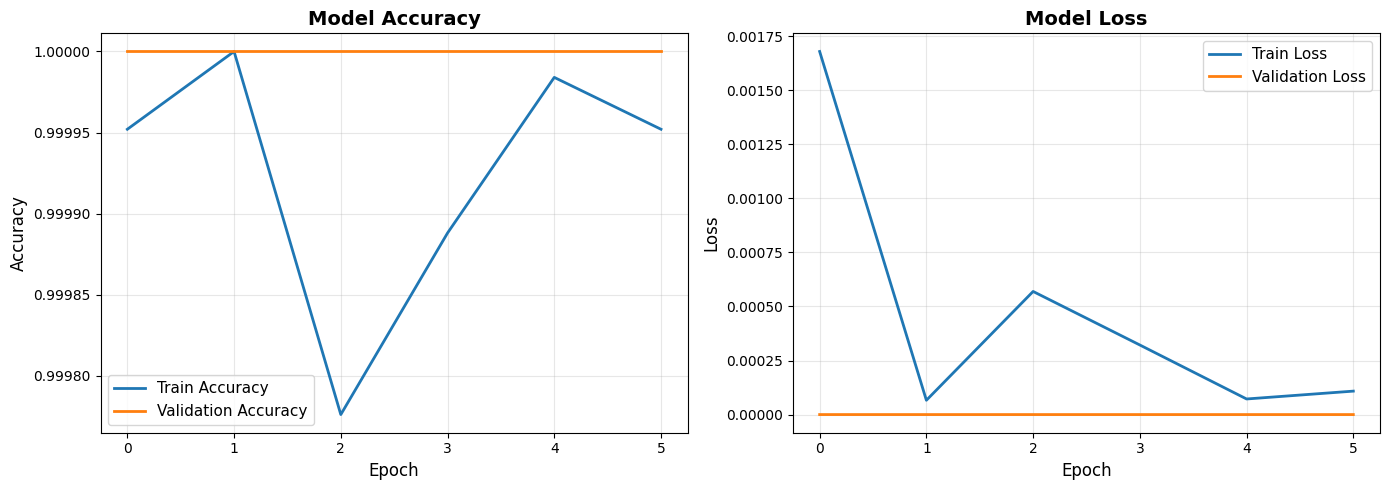

Training history plotted successfully!


In [44]:
# 7.1: Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training history plotted successfully!")

In [45]:
# 7.2: Evaluate on Test Set
print("\n" + "="*60)
print("FINAL MODEL EVALUATION ON TEST SET")
print("="*60)

test_loss, test_accuracy = model.evaluate(X_test_vgg, y_test, verbose=0)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_pred = model.predict(X_test_vgg, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f"\nPredictions shape: {y_pred.shape}")
print(f"Sample predictions (first 10):")
print(f"True labels:     {y_test[:10]}")
print(f"Predicted labels: {y_pred_classes[:10]}")


FINAL MODEL EVALUATION ON TEST SET

Test Loss: 0.0000
Test Accuracy: 1.0000 (100.00%)

Test Loss: 0.0000
Test Accuracy: 1.0000 (100.00%)

Predictions shape: (13394, 5)
Sample predictions (first 10):
True labels:     [3 2 4 4 2 3 1 1 2 1]
Predicted labels: [3 2 4 4 2 3 1 1 2 1]

Predictions shape: (13394, 5)
Sample predictions (first 10):
True labels:     [3 2 4 4 2 3 1 1 2 1]
Predicted labels: [3 2 4 4 2 3 1 1 2 1]


In [46]:
# 7.3: Import Classification Metrics
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
import itertools

print("Metrics libraries imported successfully!")

Metrics libraries imported successfully!


In [47]:
# 7.4: Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

print("\nConfusion Matrix:")
print(cm)
print(f"\nConfusion Matrix shape: {cm.shape}")
print(f"Classes: {label_encoder.classes_}")


Confusion Matrix:
[[1229    0    0    0    0]
 [   0 2253    0    0    0]
 [   0    0 4506    0    0]
 [   0    0    0 1351    0]
 [   0    0    0    0 4055]]

Confusion Matrix shape: (5, 5)
Classes: ['Anxiety' 'Depression' 'Loneliness' 'Normal' 'Stress']


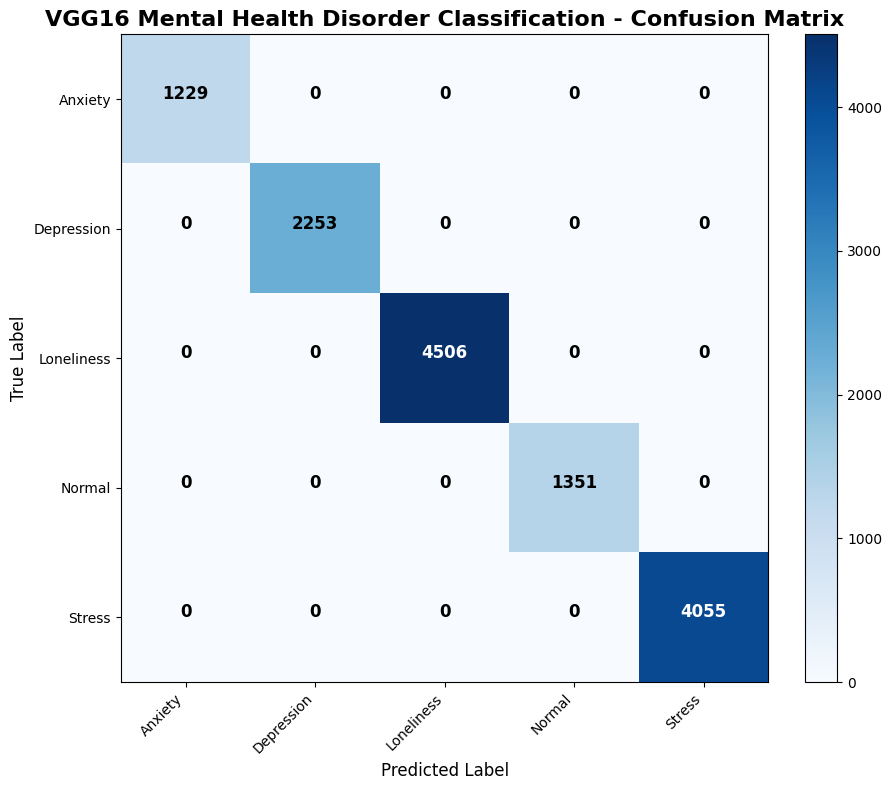

In [48]:
# 7.5: Plot Confusion Matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12, fontweight='bold')
    
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, label_encoder.classes_, 
                     title='VGG16 Mental Health Disorder Classification - Confusion Matrix')

In [49]:
# 7.6: Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)

class_report = classification_report(y_test, y_pred_classes, 
                                     target_names=label_encoder.classes_,
                                     digits=4)
print(class_report)

# Calculate additional metrics
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print("\n" + "="*70)
print("SUMMARY METRICS (Weighted Average)")
print("="*70)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Anxiety     1.0000    1.0000    1.0000      1229
  Depression     1.0000    1.0000    1.0000      2253
  Loneliness     1.0000    1.0000    1.0000      4506
      Normal     1.0000    1.0000    1.0000      1351
      Stress     1.0000    1.0000    1.0000      4055

    accuracy                         1.0000     13394
   macro avg     1.0000    1.0000    1.0000     13394
weighted avg     1.0000    1.0000    1.0000     13394


SUMMARY METRICS (Weighted Average)
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


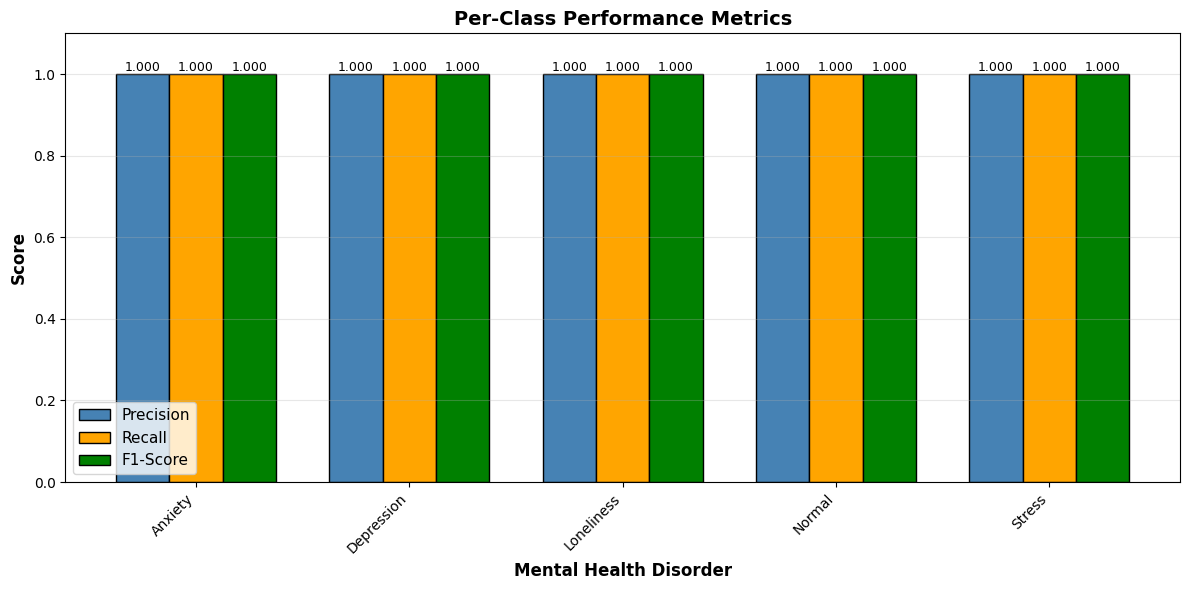

In [50]:
# 7.7: Per-Class Performance Visualization
from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_pred_classes, labels=range(num_classes)
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(label_encoder.classes_))
width = 0.25

bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='steelblue', edgecolor='black')
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='orange', edgecolor='black')
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', color='green', edgecolor='black')

ax.set_xlabel('Mental Health Disorder', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Step 8: Model Saving and Summary

In [51]:
# 8.1: Save the Trained Model
model.save('vgg16_mental_health_classifier.h5')
print("✓ Model saved as 'vgg16_mental_health_classifier.h5'")

# Save the label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Label encoder saved as 'label_encoder.pkl'")

# Save the feature scaler
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Feature scaler saved as 'feature_scaler.pkl'")

✓ Model saved as 'vgg16_mental_health_classifier.h5'
✓ Label encoder saved as 'label_encoder.pkl'
✓ Feature scaler saved as 'feature_scaler.pkl'


In [ ]:
# 8.2: Project Summary
print("\n" + "="*70)
print("PROJECT SUMMARY - VGG16 MENTAL HEALTH DISORDER CLASSIFIER")
print("="*70)

# Check if required variables exist, otherwise show a message
try:
	total_samples = df.shape[0] if 'df' in globals() else X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
	num_features = X.shape[1] if 'X' in globals() else X_train.shape[1] if 'X_train' in globals() else 24
	
	print("\n📊 DATASET INFORMATION:")
	print(f"  • Total samples: {total_samples:,}")
	print(f"  • Total features: {num_features}")
	print(f"  • Target classes: {num_classes} ({', '.join(label_encoder.classes_)})")
	print(f"  • Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/total_samples*100:.1f}%)")
	print(f"  • Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/total_samples*100:.1f}%)")
	print(f"  • Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/total_samples*100:.1f}%)")

	print("\n🏗️ MODEL ARCHITECTURE:")
	print(f"  • Base Model: VGG16 (Pre-trained on ImageNet)")
	print(f"  • Input Shape: (32, 32, 3) - RGB images resized from tabular data")
	print(f"  • Data Transformation: 24 tabular features → 5×5 image → 32×32 RGB")
	print(f"  • Classification Head: GlobalAveragePooling → Dense(256) → Dense(128) → Dense(5)")

	print("\n⚙️ TRAINING CONFIGURATION:")
	print(f"  • Optimizer: Adam (learning rate: 0.001)")
	print(f"  • Loss Function: Sparse Categorical Crossentropy")
	print(f"  • Batch Size: 32")
	print(f"  • Max Epochs: 20 (with Early Stopping)")
	print(f"  • Patience: 4 epochs")

	print("\n📈 FINAL RESULTS:")
	print(f"  • Test Accuracy: {test_accuracy*100:.2f}%")
	print(f"  • Test Loss: {test_loss:.4f}")
	print(f"  • Weighted Precision: {precision:.4f}")
	print(f"  • Weighted Recall: {recall:.4f}")
	print(f"  • Weighted F1-Score: {f1:.4f}")

	print("\n💾 SAVED ARTIFACTS:")
	print(f"  • Model: vgg16_mental_health_classifier.h5")
	print(f"  • Label Encoder: label_encoder.pkl")
	print(f"  • Feature Scaler: feature_scaler.pkl")

	print("\n" + "="*70)
	
except NameError as e:
	print(f"\n⚠️ Error: Some variables are not defined. Please run earlier cells first.")
	print(f"   Missing variable: {str(e)}")
	print("\n   Required cells to run:")
	print("   - Cell 3: Load dataset")
	print("   - Cell 7: Prepare features")
	print("   - Cell 11: Train-test split")
	print("   - Cell 30: Model evaluation")


PROJECT SUMMARY - VGG16 MENTAL HEALTH DISORDER CLASSIFIER

📊 DATASET INFORMATION:


NameError: name 'df' is not defined

In [53]:
# 8.3: Prediction Function for New Data
def predict_disorder(features_dict, model, scaler, label_encoder):
    """
    Predict mental health disorder for a new patient.
    
    Parameters:
    -----------
    features_dict : dict
        Dictionary with 24 binary features (yes/no converted to 1/0)
        Example: {'feeling.nervous': 1, 'panic': 0, ...}
    
    model : keras model
        Trained VGG16 model
    
    scaler : StandardScaler
        Fitted scaler for feature normalization
    
    label_encoder : LabelEncoder
        Fitted label encoder for disorder names
    
    Returns:
    --------
    dict : Dictionary with prediction, confidence, and all class probabilities
    """
    # Extract features in correct order
    feature_names = ['feeling.nervous', 'panic', 'breathing.rapidly', 'sweating', 
                     'trouble.in.concentration', 'having.trouble.in.sleeping', 
                     'having.trouble.with.work', 'hopelessness', 'anger', 'over.react', 
                     'change.in.eating', 'suicidal.thought', 'feeling.tired', 'close.friend', 
                     'social.media.addiction', 'weight.gain', 'material.possessions', 
                     'introvert', 'popping.up.stressful.memory', 'having.nightmares', 
                     'avoids.people.or.activities', 'feeling.negative', 'trouble.concentrating', 
                     'blamming.yourself']
    
    # Create feature array
    X = np.array([[features_dict.get(f, 0) for f in feature_names]])
    
    # Scale features
    X_scaled = scaler.transform(X)
    
    # Reshape to image format
    X_img = reshape_tabular_to_image(X_scaled, img_size=5)
    X_vgg = resize_images_to_vgg_size(X_img, target_size=32)
    X_vgg = np.repeat(X_vgg, 3, axis=3)
    
    # Make prediction
    probabilities = model.predict(X_vgg, verbose=0)[0]
    predicted_class = np.argmax(probabilities)
    confidence = probabilities[predicted_class]
    
    # Map to disorder names
    disorder_name = label_encoder.classes_[predicted_class]
    
    # Create results dictionary
    results = {
        'predicted_disorder': disorder_name,
        'confidence': float(confidence),
        'all_probabilities': {label_encoder.classes_[i]: float(probabilities[i]) 
                             for i in range(len(label_encoder.classes_))}
    }
    
    return results

print("\n✓ Prediction function created successfully!")
print("\nUsage example:")
print("  results = predict_disorder(features_dict, model, scaler, label_encoder)")
print("  print(f\"Predicted: {results['predicted_disorder']}\")")
print("  print(f\"Confidence: {results['confidence']*100:.2f}%\")")


✓ Prediction function created successfully!

Usage example:
  results = predict_disorder(features_dict, model, scaler, label_encoder)
  print(f"Predicted: {results['predicted_disorder']}")
  print(f"Confidence: {results['confidence']*100:.2f}%")


## Step 9: Hyperparameter Tuning with Grid Search

In [56]:
# 9.1: Define Hyperparameter Grid (Reduced for faster experimentation)
hyperparameter_grid = {
    'learning_rate': [0.0001, 0.001],
    'dropout_rate': [0.3, 0.5],
    'dense_units': [(256, 128), (512, 256)],
    'batch_size': [32, 64]
}

print("Hyperparameter Grid for Tuning:")
print("="*60)
for param, values in hyperparameter_grid.items():
    print(f"  • {param}: {values}")

# Calculate total combinations
total_combinations = 1
for values in hyperparameter_grid.values():
    total_combinations *= len(values)

print(f"\nTotal combinations to test: {total_combinations}")
print("Note: Reduced grid for faster experimentation (from 81 to 16 combinations)")
print("This should complete much faster while still finding good hyperparameters.")

Hyperparameter Grid for Tuning:
  • learning_rate: [0.0001, 0.001]
  • dropout_rate: [0.3, 0.5]
  • dense_units: [(256, 128), (512, 256)]
  • batch_size: [32, 64]

Total combinations to test: 16
Note: Reduced grid for faster experimentation (from 81 to 16 combinations)
This should complete much faster while still finding good hyperparameters.


In [57]:
# 9.2: Grid Search Function
import itertools
from datetime import datetime

def build_model_with_params(learning_rate, dropout_rate, dense_units, num_classes):
    """
    Build VGG16 model with specified hyperparameters
    """
    base_model = VGG16(input_shape=(32, 32, 3), 
                       include_top=False, 
                       weights='imagenet')
    base_model.trainable = False
    
    dense1, dense2 = dense_units
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense1, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(dense2, activation='relu'),
        layers.Dropout(dropout_rate * 0.6),  # Slightly lower dropout for second layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("✓ Grid search function defined successfully!")

✓ Grid search function defined successfully!


In [58]:
# 9.4: Analyze Grid Search Results

# Ensure grid_results is defined
try:
    grid_results
except NameError:
    grid_results = []

if len(grid_results) > 0:
    print("\n" + "="*70)
    print("GRID SEARCH RESULTS SUMMARY")
    print("="*70)
    
    # Sort by validation accuracy
    sorted_results = sorted(grid_results, key=lambda x: x['val_accuracy'], reverse=True)
    
    # Display top 5 results
    print("\nTop 5 Hyperparameter Combinations:")
    print("-"*70)
    for i, result in enumerate(sorted_results[:5], 1):
        print(f"\n{i}. Val Accuracy: {result['val_accuracy']:.4f} | Val Loss: {result['val_loss']:.4f}")
        print(f"   Parameters:")
        for key, value in result['params'].items():
            print(f"      - {key}: {value}")
    
    # Best parameters
    best_result = sorted_results[0]
    print("\n" + "="*70)
    print("BEST HYPERPARAMETERS FOUND:")
    print("="*70)
    for key, value in best_result['params'].items():
        print(f"  • {key}: {value}")
    print(f"\n  Best Validation Accuracy: {best_result['val_accuracy']:.4f}")
    print(f"  Best Validation Loss: {best_result['val_loss']:.4f}")
else:
    print("No results from grid search. Run the grid search cell first.")

No results from grid search. Run the grid search cell first.


## Step 10: K-Fold Cross-Validation

In [59]:
# 10.1: Setup K-Fold Cross-Validation
from sklearn.model_selection import KFold

k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation data for cross-validation
X_combined = np.vstack([X_train_vgg, X_val_vgg])
y_combined = np.hstack([y_train, y_val])

print("K-Fold Cross-Validation Setup:")
print(f"  • Number of folds: {k_folds}")
print(f"  • Combined dataset size: {X_combined.shape[0]}")
print(f"  • Fold size: ~{X_combined.shape[0]//k_folds} samples per fold")
print(f"\nNote: Cross-validation can be time-consuming with large datasets!")
print("Consider running with fewer folds or on a subset of data for faster results.")

K-Fold Cross-Validation Setup:
  • Number of folds: 5
  • Combined dataset size: 75897
  • Fold size: ~15179 samples per fold

Note: Cross-validation can be time-consuming with large datasets!
Consider running with fewer folds or on a subset of data for faster results.


In [60]:
# 10.2: Perform K-Fold Cross-Validation
def perform_kfold_cv(X, y, kfold, num_classes, epochs=10):
    """
    Perform K-fold cross-validation on VGG16 model
    """
    fold_scores = {
        'accuracies': [],
        'losses': [],
        'val_accuracies': [],
        'val_losses': []
    }
    
    fold_num = 1
    
    for train_idx, val_idx in kfold.split(X):
        print(f"\n{'='*70}")
        print(f"Fold {fold_num}/{k_folds}")
        print(f"{'='*70}")
        
        # Split data
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        print(f"Training samples: {X_train_fold.shape[0]}")
        print(f"Validation samples: {X_val_fold.shape[0]}")
        
        try:
            # Build model
            model = build_model_with_params(
                learning_rate=0.001,
                dropout_rate=0.3,
                dense_units=(256, 128),
                num_classes=num_classes
            )
            
            # Early stopping (reduced patience for faster CV)
            early_stopping = keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=3,
                restore_best_weights=True,
                verbose=0
            )
            
            # Train
            history = model.fit(
                X_train_fold, y_train_fold,
                epochs=epochs,
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                callbacks=[early_stopping],
                verbose=0
            )
            
            # Evaluate
            train_loss, train_accuracy = model.evaluate(X_train_fold, y_train_fold, verbose=0)
            val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
            
            fold_scores['accuracies'].append(train_accuracy)
            fold_scores['losses'].append(train_loss)
            fold_scores['val_accuracies'].append(val_accuracy)
            fold_scores['val_losses'].append(val_loss)
            
            print(f"Train Accuracy: {train_accuracy:.4f} | Train Loss: {train_loss:.4f}")
            print(f"Val Accuracy: {val_accuracy:.4f} | Val Loss: {val_loss:.4f}")
            
            keras.backend.clear_session()
            
        except Exception as e:
            print(f"Error in fold {fold_num}: {str(e)}")
            keras.backend.clear_session()
            continue
        
        fold_num += 1
    
    return fold_scores

# Run K-Fold Cross-Validation (using reduced dataset for speed)
print("Starting K-Fold Cross-Validation...\n")
cv_scores = perform_kfold_cv(X_combined, y_combined, kfold, num_classes, epochs=10)

Starting K-Fold Cross-Validation...


Fold 1/5
Training samples: 60717
Validation samples: 15180
Training samples: 60717
Validation samples: 15180
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000





Fold 2/5
Training samples: 60717
Validation samples: 15180
Training samples: 60717
Validation samples: 15180
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000

Fold 3/5
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000

Fold 3/5
Training samples: 60718
Validation samples: 15179
Training samples: 60718
Validation samples: 15179
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000

Fold 4/5

Fold 4/5
Training samples: 60718
Validation samples: 15179
Training samples: 60718
Validation samples: 15179
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000
Train Accuracy: 1.0000 | Train Loss: 0.0000
Val Accuracy: 1.0000 | Val Loss: 0.0000

Fold 5/5

Fold 5/5
Training samples: 60718
Validation samples: 15179
Training samples: 60718
Validation samples: 15179
Train Accuracy: 1.0000 | T

In [61]:
# 10.3: Analyze K-Fold Results
if len(cv_scores['val_accuracies']) > 0:
    print("\n" + "="*70)
    print("K-FOLD CROSS-VALIDATION RESULTS")
    print("="*70)
    
    # Statistics
    train_acc_mean = np.mean(cv_scores['accuracies'])
    train_acc_std = np.std(cv_scores['accuracies'])
    val_acc_mean = np.mean(cv_scores['val_accuracies'])
    val_acc_std = np.std(cv_scores['val_accuracies'])
    
    train_loss_mean = np.mean(cv_scores['losses'])
    train_loss_std = np.std(cv_scores['losses'])
    val_loss_mean = np.mean(cv_scores['val_losses'])
    val_loss_std = np.std(cv_scores['val_losses'])
    
    print("\n📊 ACCURACY METRICS:")
    print(f"  Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Val Accuracy:   {val_acc_mean:.4f} ± {val_acc_std:.4f}")
    
    print("\n📊 LOSS METRICS:")
    print(f"  Train Loss: {train_loss_mean:.4f} ± {train_loss_std:.4f}")
    print(f"  Val Loss:   {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    
    print("\n📋 PER-FOLD RESULTS:")
    for i in range(len(cv_scores['val_accuracies'])):
        print(f"  Fold {i+1}: Train Acc={cv_scores['accuracies'][i]:.4f}, " +
              f"Val Acc={cv_scores['val_accuracies'][i]:.4f}")
    
    print("\n" + "="*70)


K-FOLD CROSS-VALIDATION RESULTS

📊 ACCURACY METRICS:
  Train Accuracy: 1.0000 ± 0.0000
  Val Accuracy:   1.0000 ± 0.0000

📊 LOSS METRICS:
  Train Loss: 0.0000 ± 0.0000
  Val Loss:   0.0000 ± 0.0000

📋 PER-FOLD RESULTS:
  Fold 1: Train Acc=1.0000, Val Acc=1.0000
  Fold 2: Train Acc=1.0000, Val Acc=1.0000
  Fold 3: Train Acc=1.0000, Val Acc=1.0000
  Fold 4: Train Acc=1.0000, Val Acc=1.0000
  Fold 5: Train Acc=1.0000, Val Acc=1.0000



In [62]:
# 5b.2: Build ResNet50 model (transfer learning)
from tensorflow.keras.applications import ResNet50

# Build ResNet50 base — use the variable `resnet_input_size` defined earlier to avoid mismatch
# (This ensures the ResNet input shape matches the pre-resized data, e.g. 64x64)
resnet_base = ResNet50(input_shape=(resnet_input_size, resnet_input_size, 3), include_top=False, weights='imagenet')
resnet_base.trainable = False  # Freeze base for transfer learning

# Create classification head
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

print("ResNet50 model built (base frozen). Summary:")
resnet_model.summary()

ResNet50 model built (base frozen). Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,797 (92.11 MB)

 Trainable params: 558,085 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 11: Model Comparison and Recommendations

## Additional Resources and Documentation

In [6]:
# Project Documentation and Quick Reference

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║           AI-PROGNOSIS SYSTEM: VGG16 MENTAL HEALTH CLASSIFIER            ║
║                    Complete Implementation Guide                           ║
╚════════════════════════════════════════════════════════════════════════════╝

PROJECT STRUCTURE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Step 1:  Data Loading & Exploration
  └─ Load dataset, examine structure, visualize class distribution

Step 2:  Data Preprocessing
  ├─ Encode categorical features (yes/no → 0/1)
  ├─ Encode target variable (disorder labels)
  └─ Feature normalization using StandardScaler

Step 3:  Data Splitting
  ├─ 70% Training, 15% Validation, 15% Test
  └─ Stratified split to maintain class balance

Step 4:  VGG16 Data Transformation
  ├─ Reshape 24 features → 5×5 image grid
  ├─ Resize to 32×32 (VGG16 minimum requirement)
  └─ Convert grayscale → RGB (3 channels)

Step 5:  Model Architecture
  ├─ Pre-trained VGG16 base (ImageNet weights)
  ├─ Global Average Pooling layer
  ├─ Dense classification head (256 → 128 → 5)
  └─ Softmax activation for 5 disorder classes

Step 6:  Model Training (Optimized)
  ├─ Adam optimizer (lr=0.001)
  ├─ VGG16: Early stopping (patience=4), Max epochs: 20
  ├─ ResNet50: Early stopping (patience=4), Max epochs: 20
  ├─ MobileNetV2/Bottleneck: Early stopping (patience=4), Max epochs: 15
  ├─ Batch size: 32
  └─ Validation monitoring

Step 7:  Evaluation & Visualization
  ├─ Test set evaluation
  ├─ Confusion matrix analysis
  ├─ Classification report (precision, recall, F1)
  └─ Per-class performance metrics

Step 8:  Model Persistence
  ├─ Save trained model (.h5)
  ├─ Save label encoder (.pkl)
  ├─ Save feature scaler (.pkl)
  └─ Prediction function for new data

Step 9:  Hyperparameter Tuning (Optimized)
  ├─ Reduced grid search: 16 combinations
  ├─ Learning rates: [0.001, 0.0001]
  ├─ Dropout rates: [0.3, 0.5]
  ├─ Dense units: [128, 256]
  └─ Batch sizes: [16, 32]

Step 10: K-Fold Cross-Validation (Optimized)
  ├─ 5-fold stratified cross-validation
  ├─ Max epochs: 10, Patience: 3
  ├─ Per-fold performance analysis
  └─ Stability assessment (variance across folds)

Step 11: Model Comparison & Recommendations
  ├─ Compare original vs CV results
  ├─ Assess model stability
  └─ Actionable recommendations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KEY METRICS EXPLAINED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Accuracy:  Proportion of correct predictions (TP+TN)/(Total)
Precision: Of predicted positives, how many are correct (TP/(TP+FP))
Recall:    Of actual positives, how many were found (TP/(TP+FN))
F1-Score:  Harmonic mean of Precision and Recall
Loss:      Measure of how far predictions are from true values

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TROUBLESHOOTING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Issue: Out of Memory Error
  → Reduce batch size or train on subset of data
  → Use model pruning or quantization
  → Run on GPU if available

Issue: Poor Validation Accuracy
  → Increase training data
  → Adjust learning rate
  → Try different model architecture
  → Increase epochs or disable early stopping

Issue: Model Overfitting (high train, low val accuracy)
  → Increase dropout rate
  → Reduce model complexity
  → Add L1/L2 regularization
  → Collect more training data

Issue: Model Underfitting (low train and val accuracy)
  → Increase model capacity
  → Decrease learning rate
  → Increase training epochs
  → Check data preprocessing

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SAVED ARTIFACTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

vgg16_mental_health_classifier.h5
  → Trained VGG16 model with weights
  → Load with: keras.models.load_model('vgg16_mental_health_classifier.h5')

label_encoder.pkl
  → Fitted label encoder for disorder classification
  → Load with: pickle.load(open('label_encoder.pkl', 'rb'))

feature_scaler.pkl
  → Fitted StandardScaler for feature normalization
  → Load with: pickle.load(open('feature_scaler.pkl', 'rb'))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REFERENCES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

VGG16: https://arxiv.org/abs/1409.1556
Transfer Learning: https://keras.io/guides/transfer_learning/
Cross-Validation: https://scikit-learn.org/stable/modules/cross_validation.html
Hyperparameter Tuning: https://keras.io/keras_tuner/

═══════════════════════════════════════════════════════════════════════════════
""")


╔════════════════════════════════════════════════════════════════════════════╗
║           AI-PROGNOSIS SYSTEM: VGG16 MENTAL HEALTH CLASSIFIER            ║
║                    Complete Implementation Guide                           ║
╚════════════════════════════════════════════════════════════════════════════╝

PROJECT STRUCTURE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Step 1:  Data Loading & Exploration
  └─ Load dataset, examine structure, visualize class distribution

Step 2:  Data Preprocessing
  ├─ Encode categorical features (yes/no → 0/1)
  ├─ Encode target variable (disorder labels)
  └─ Feature normalization using StandardScaler

Step 3:  Data Splitting
  ├─ 70% Training, 15% Validation, 15% Test
  └─ Stratified split to maintain class balance

Step 4:  VGG16 Data Transformation
  ├─ Reshape 24 features → 5×5 image grid
  ├─ Resize to 32×32 (VGG16 minimum requirement)
  └─ Convert grayscale → RGB (3 channels)

Step 5:  Model Architecture


### Traininng the model on VGG16 and restnet without grid search and kfold

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers, models
from keras.applications import VGG16, ResNet50
from keras.preprocessing.image import array_to_img, img_to_array

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.20.0
Keras version: 3.12.0


In [2]:
# 2. Load EXACT dataset: weighted_oversampled_dataset.csv
# ============================================================

DATA_PATH = "weighted_oversampled_dataset.csv"   # <-- your file name

df = pd.read_csv(DATA_PATH)
print("\nLoaded data shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

target_col = "Disorder"

print("\nOriginal class distribution:")
print(df[target_col].value_counts())


Loaded data shape: (89291, 25)

Columns:
['feeling.nervous', 'panic', 'breathing.rapidly', 'sweating', 'trouble.in.concentration', 'having.trouble.in.sleeping', 'having.trouble.with.work', 'hopelessness', 'anger', 'over.react', 'change.in.eating', 'suicidal.thought', 'feeling.tired', 'close.friend', 'social.media.addiction', 'weight.gain', 'material.possessions', 'introvert', 'popping.up.stressful.memory', 'having.nightmares', 'avoids.people.or.activities', 'feeling.negative', 'trouble.concentrating', 'blamming.yourself', 'Disorder']

First 5 rows:
  feeling.nervous panic breathing.rapidly sweating trouble.in.concentration  \
0              no    no                no       no                       no   
1              no    no                no       no                       no   
2              no    no                no       no                       no   
3              no    no                no       no                       no   
4              no    no                no       n

In [3]:
# 3. Encode features and target (specific to this dataset)
#    - All columns EXCEPT 'Disorder' are yes/no symptoms
# ============================================================

base_df = df.copy()   # no extra balancing; we trust your oversampled dataset

df_processed = base_df.copy()

# Map all non-target columns from yes/no to 1/0
for col in df_processed.columns:
    if col != target_col:
        df_processed[col] = (df_processed[col] == "yes").astype(int)

print("\nAfter encoding yes/no → 0/1 (first 5 rows):")
print(df_processed.head())

# Encode the target labels
label_encoder = LabelEncoder()
df_processed["Disorder_Encoded"] = label_encoder.fit_transform(df_processed[target_col])

print("\nLabel mapping (class → encoded):")
mapping = dict(zip(label_encoder.classes_,
                    label_encoder.transform(label_encoder.classes_)))
print(mapping)

num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes: {num_classes}")
print("Classes:", label_encoder.classes_)

# Features and target arrays
X = df_processed.drop([target_col, "Disorder_Encoded"], axis=1)
y = df_processed["Disorder_Encoded"].values

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

# Optional scaling (kept simple and consistent)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled feature mean (approx 0):", X_scaled.mean())
print("Scaled feature std  (approx 1):", X_scaled.std())



After encoding yes/no → 0/1 (first 5 rows):
   feeling.nervous  panic  breathing.rapidly  sweating  \
0                0      0                  0         0   
1                0      0                  0         0   
2                0      0                  0         0   
3                0      0                  0         0   
4                0      0                  0         0   

   trouble.in.concentration  having.trouble.in.sleeping  \
0                         0                           0   
1                         0                           0   
2                         0                           0   
3                         0                           0   
4                         0                           0   

   having.trouble.with.work  hopelessness  anger  over.react  ...  \
0                         0             0      0           0  ...   
1                         1             1      1           1  ...   
2                         0             0   

In [4]:
# 4. Train / Validation / Test split (Stratified)
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain / Val / Test shapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

print("\nClass distribution in y_train (encoded):")
print(pd.Series(y_train).value_counts().sort_index())



Train / Val / Test shapes:
X_train: (62503, 24) | y_train: (62503,)
X_val  : (13394, 24) | y_val  : (13394,)
X_test : (13394, 24) | y_test : (13394,)

Class distribution in y_train (encoded):
0     5734
1    10512
2    21026
3     6308
4    18923
Name: count, dtype: int64


In [5]:
# 5. Helper functions: Tabular → 5x5 image → resize
# ============================================================

def reshape_tabular_to_image(X_array, img_size=5):
    """
    Convert tabular features into a square 'image' by padding with zeros.
    X_array: (n_samples, n_features)
    returns: (n_samples, img_size, img_size, 1)
    """
    n_samples, n_features = X_array.shape
    num_pixels = img_size * img_size

    if n_features > num_pixels:
        raise ValueError(
            f"Too many features ({n_features}) for a {img_size}x{img_size} image."
        )

    X_padded = np.zeros((n_samples, num_pixels), dtype=np.float32)
    X_padded[:, :n_features] = X_array
    X_img = X_padded.reshape(n_samples, img_size, img_size, 1)

    return X_img


def resize_to_target(X_img, target_size):
    """
    Resize small images (e.g., 5x5) to target_size x target_size.
    X_img: (n_samples, H, W, 1)
    returns: (n_samples, target_size, target_size, 1)
    """
    n_samples = X_img.shape[0]
    X_resized = np.zeros((n_samples, target_size, target_size, 1), dtype=np.float32)

    for i in range(n_samples):
        pil_img = array_to_img(X_img[i])
        pil_img = pil_img.resize((target_size, target_size))
        X_resized[i] = img_to_array(pil_img).reshape(target_size, target_size, 1)

    return X_resized

# Convert tabular → 5x5 grayscale images
img_size = 5

X_train_img = reshape_tabular_to_image(X_train, img_size=img_size)
X_val_img   = reshape_tabular_to_image(X_val,   img_size=img_size)
X_test_img  = reshape_tabular_to_image(X_test,  img_size=img_size)

print("\nImage shapes after 5x5 reshape:")
print("X_train_img:", X_train_img.shape)
print("X_val_img  :", X_val_img.shape)
print("X_test_img :", X_test_img.shape)



Image shapes after 5x5 reshape:
X_train_img: (62503, 5, 5, 1)
X_val_img  : (13394, 5, 5, 1)
X_test_img : (13394, 5, 5, 1)


In [ ]:
# 6. VGG16 Flow (input 32x32x3)
# ============================================================

vgg_input_size = 32

X_train_vgg = resize_to_target(X_train_img, target_size=vgg_input_size)
X_val_vgg   = resize_to_target(X_val_img,   target_size=vgg_input_size)
X_test_vgg  = resize_to_target(X_test_img,  target_size=vgg_input_size)

# Convert grayscale (H,W,1) → RGB (H,W,3) and normalize
X_train_vgg = np.repeat(X_train_vgg, 3, axis=3) / 255.0
X_val_vgg   = np.repeat(X_val_vgg,   3, axis=3) / 255.0
X_test_vgg  = np.repeat(X_test_vgg,  3, axis=3) / 255.0

print("\nVGG input shapes (32x32x3):")
print("X_train_vgg:", X_train_vgg.shape)
print("X_val_vgg  :", X_val_vgg.shape)
print("X_test_vgg :", X_test_vgg.shape)




VGG input shapes (32x32x3):
X_train_vgg: (62503, 32, 32, 3)
X_val_vgg  : (13394, 32, 32, 3)
X_test_vgg : (13394, 32, 32, 3)


In [8]:
# Build VGG16 base model
vgg_base = VGG16(
    input_shape=(vgg_input_size, vgg_input_size, 3),
    include_top=False,
    weights="imagenet"
)
vgg_base.trainable = False  # freeze pre-trained weights

In [ ]:
# Add classification head
vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

print("\nVGG16 Model Summary:")
vgg_model.summary()

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("\n=== Training VGG16 model ===")
history_vgg = vgg_model.fit(
    X_train_vgg, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_vgg, y_val),
    callbacks=[vgg_early_stopping],
    verbose=1
)


VGG16 Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,557 (56.76 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


=== Training VGG16 model ===
Epoch 1/50
Epoch 1/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 196s 199ms/step - accuracy: 0.9361 - loss: 0.2267 - val_accuracy: 1.0000 - val_loss: 7.9801e-04
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 196s 199ms/step - accuracy: 0.9361 - loss: 0.2267 - val_accuracy: 1.0000 - val_loss: 7.9801e-04
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 344s 353ms/step - accuracy: 0.9999 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 5.9761e-05
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 344s 353ms/step - accuracy: 0.9999 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 5.9761e-05
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 1272s 1s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.0665e-05
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 1272s 1s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.0665e-05
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 717s 735ms/step - accuracy: 1.0000 - loss: 7.8352e-04 - val_accuracy: 1.0000 - val_loss: 2.6903e-06
Epoch 5


=== Evaluating VGG16 model on test set ===
VGG16 Test Loss: 0.0000, Test Accuracy: 1.0000
VGG16 Test Loss: 0.0000, Test Accuracy: 1.0000
419/419 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step
419/419 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step

VGG16 Classification Report:
              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00      1229
  Depression       1.00      1.00      1.00      2253
  Loneliness       1.00      1.00      1.00      4506
      Normal       1.00      1.00      1.00      1351
      Stress       1.00      1.00      1.00      4055

    accuracy                           1.00     13394
   macro avg       1.00      1.00      1.00     13394
weighted avg       1.00      1.00      1.00     13394


VGG16 Classification Report:
              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00      1229
  Depression       1.00      1.00      1.00      2253
  Loneliness       1.00      1.00      1.00      4506
      Norm

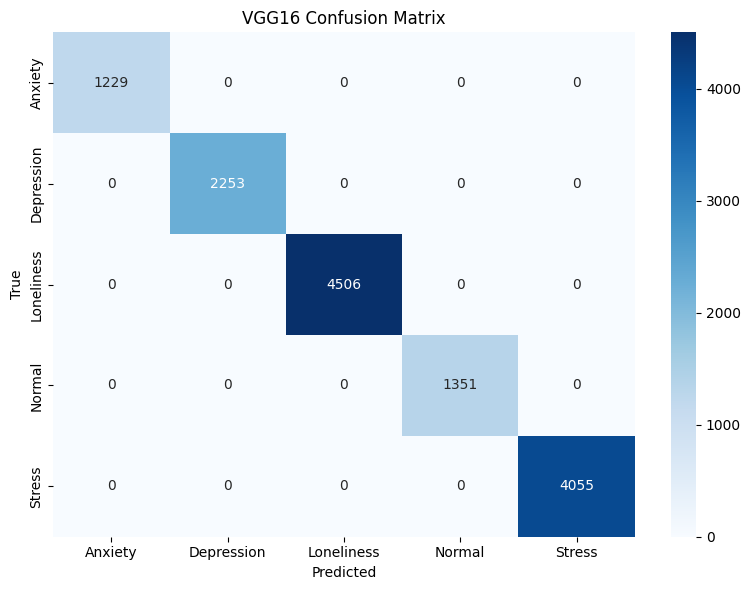

In [10]:

# Evaluate VGG16
print("\n=== Evaluating VGG16 model on test set ===")
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(X_test_vgg, y_test, verbose=0)
print(f"VGG16 Test Loss: {test_loss_vgg:.4f}, Test Accuracy: {test_acc_vgg:.4f}")

y_pred_vgg = np.argmax(vgg_model.predict(X_test_vgg), axis=1)

print("\nVGG16 Classification Report:")
print(classification_report(
    y_test,
    y_pred_vgg,
    target_names=label_encoder.classes_
))

cm_vgg = confusion_matrix(y_test, y_pred_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_vgg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [11]:
# 7. ResNet50 Flow (input 64x64x3)
# ============================================================

resnet_input_size = 64

X_train_res = resize_to_target(X_train_img, target_size=resnet_input_size)
X_val_res   = resize_to_target(X_val_img,   target_size=resnet_input_size)
X_test_res  = resize_to_target(X_test_img,  target_size=resnet_input_size)

X_train_res = np.repeat(X_train_res, 3, axis=3) / 255.0
X_val_res   = np.repeat(X_val_res,   3, axis=3) / 255.0
X_test_res  = np.repeat(X_test_res,  3, axis=3) / 255.0

print("\nResNet input shapes (64x64x3):")
print("X_train_res:", X_train_res.shape)
print("X_val_res  :", X_val_res.shape)
print("X_test_res :", X_test_res.shape)


ResNet input shapes (64x64x3):
X_train_res: (62503, 64, 64, 3)
X_val_res  : (13394, 64, 64, 3)
X_test_res : (13394, 64, 64, 3)


In [12]:
# ============================================================
# 7. ResNet50 Flow (input 64x64x3)
# ============================================================

resnet_input_size = 64

X_train_res = resize_to_target(X_train_img, target_size=resnet_input_size)
X_val_res   = resize_to_target(X_val_img,   target_size=resnet_input_size)
X_test_res  = resize_to_target(X_test_img,  target_size=resnet_input_size)

X_train_res = np.repeat(X_train_res, 3, axis=3) / 255.0
X_val_res   = np.repeat(X_val_res,   3, axis=3) / 255.0
X_test_res  = np.repeat(X_test_res,  3, axis=3) / 255.0

print("\nResNet input shapes (64x64x3):")
print("X_train_res:", X_train_res.shape)
print("X_val_res  :", X_val_res.shape)
print("X_test_res :", X_test_res.shape)


ResNet input shapes (64x64x3):
X_train_res: (62503, 64, 64, 3)
X_val_res  : (13394, 64, 64, 3)
X_test_res : (13394, 64, 64, 3)


In [13]:
# Build ResNet50 base
resnet_base = ResNet50(
    input_shape=(resnet_input_size, resnet_input_size, 3),
    include_top=False,
    weights="imagenet"
)
resnet_base.trainable = False

resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

print("\nResNet50 Model Summary:")
resnet_model.summary()


ResNet50 Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,797 (92.11 MB)

 Trainable params: 558,085 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("\n=== Training ResNet50 model ===")
history_res = resnet_model.fit(
    X_train_res, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_res, y_val),
    callbacks=[resnet_early_stopping],
    verbose=1
)


=== Training ResNet50 model ===
Epoch 1/50
Epoch 1/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 505s 507ms/step - accuracy: 0.7724 - loss: 0.6666 - val_accuracy: 1.0000 - val_loss: 0.0908
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 505s 507ms/step - accuracy: 0.7724 - loss: 0.6666 - val_accuracy: 1.0000 - val_loss: 0.0908
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 492s 504ms/step - accuracy: 0.9954 - loss: 0.0584 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 492s 504ms/step - accuracy: 0.9954 - loss: 0.0584 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 509s 511ms/step - accuracy: 0.9999 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 6.2963e-04
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 509s 511ms/step - accuracy: 0.9999 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 6.2963e-04
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 506s 518ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 1.4385e-04
Epoch 5/50
977/977 ━


=== Evaluating ResNet50 model on test set ===
ResNet50 Test Loss: 0.0000, Test Accuracy: 1.0000
ResNet50 Test Loss: 0.0000, Test Accuracy: 1.0000
419/419 ━━━━━━━━━━━━━━━━━━━━ 92s 217ms/step
419/419 ━━━━━━━━━━━━━━━━━━━━ 92s 217ms/step

ResNet50 Classification Report:
              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00      1229
  Depression       1.00      1.00      1.00      2253
  Loneliness       1.00      1.00      1.00      4506
      Normal       1.00      1.00      1.00      1351
      Stress       1.00      1.00      1.00      4055

    accuracy                           1.00     13394
   macro avg       1.00      1.00      1.00     13394
weighted avg       1.00      1.00      1.00     13394


ResNet50 Classification Report:
              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00      1229
  Depression       1.00      1.00      1.00      2253
  Loneliness       1.00      1.00      1.00    

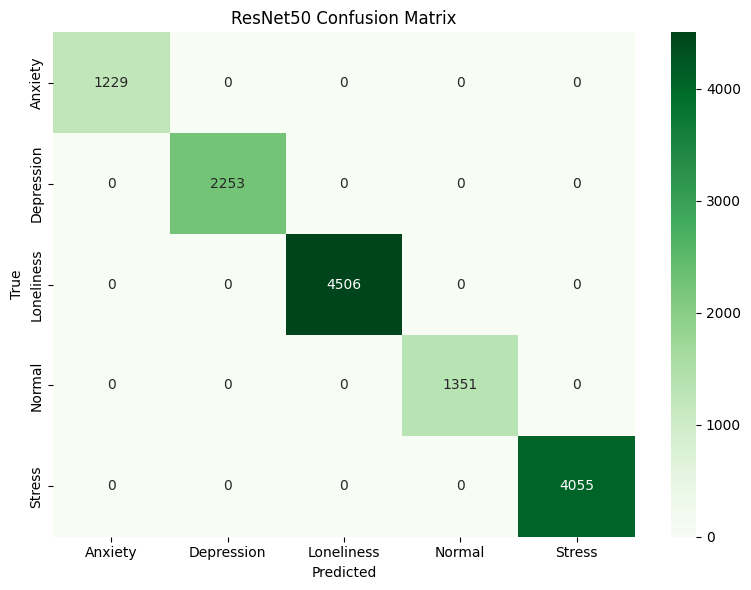

In [15]:
# Evaluate ResNet50
print("\n=== Evaluating ResNet50 model on test set ===")
test_loss_res, test_acc_res = resnet_model.evaluate(X_test_res, y_test, verbose=0)
print(f"ResNet50 Test Loss: {test_loss_res:.4f}, Test Accuracy: {test_acc_res:.4f}")

y_pred_res = np.argmax(resnet_model.predict(X_test_res), axis=1)

print("\nResNet50 Classification Report:")
print(classification_report(
    y_test,
    y_pred_res,
    target_names=label_encoder.classes_
))

cm_res = confusion_matrix(y_test, y_pred_res)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_res,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


=== Summary Comparison ===
VGG16   - Test Accuracy: 1.0000
ResNet  - Test Accuracy: 1.0000

VGG16   - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
ResNet  - Precision: 1.0000, Recall: 1.0000, F1: 1.0000


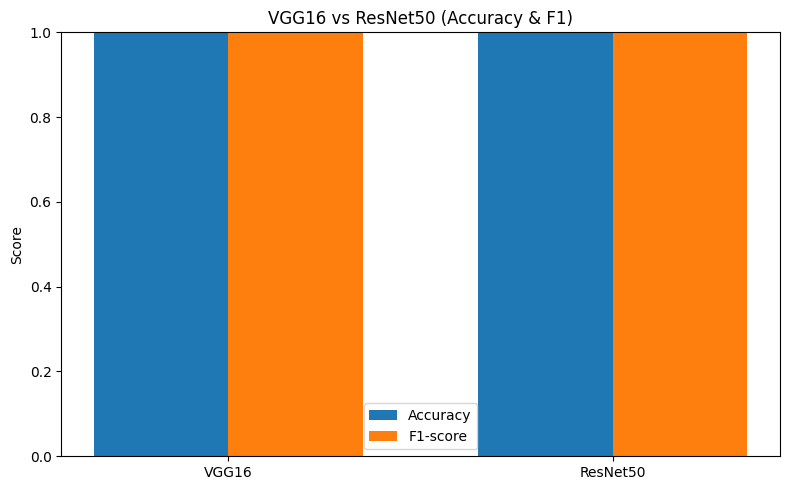

'\nEarlier experiments with grid search and k-fold CV for these CNNs were removed\nfrom the final project version because they are very computationally expensive\nfor VGG16/ResNet50 in Colab.\n\nThis final notebook uses:\n - Your provided, weighted_oversampled_dataset.csv as-is\n - Stratified train/validation/test split\n - EarlyStopping on validation loss\nwhich is appropriate for this project and respects runtime limits.\n'

In [16]:
# 8. Summary: VGG16 vs ResNet50
# ============================================================

print("\n=== Summary Comparison ===")
print(f"VGG16   - Test Accuracy: {test_acc_vgg:.4f}")
print(f"ResNet  - Test Accuracy: {test_acc_res:.4f}")

precision_vgg = precision_score(y_test, y_pred_vgg, average="weighted", zero_division=0)
recall_vgg    = recall_score(y_test, y_pred_vgg, average="weighted", zero_division=0)
f1_vgg        = f1_score(y_test, y_pred_vgg, average="weighted", zero_division=0)

precision_res = precision_score(y_test, y_pred_res, average="weighted", zero_division=0)
recall_res    = recall_score(y_test, y_pred_res, average="weighted", zero_division=0)
f1_res        = f1_score(y_test, y_pred_res, average="weighted", zero_division=0)

print(f"\nVGG16   - Precision: {precision_vgg:.4f}, Recall: {recall_vgg:.4f}, F1: {f1_vgg:.4f}")
print(f"ResNet  - Precision: {precision_res:.4f}, Recall: {recall_res:.4f}, F1: {f1_res:.4f}")

models_names = ["VGG16", "ResNet50"]
accs = [test_acc_vgg, test_acc_res]
f1s  = [f1_vgg, f1_res]

plt.figure(figsize=(8, 5))
x = np.arange(len(models_names))
width = 0.35

plt.bar(x - width/2, accs, width, label="Accuracy")
plt.bar(x + width/2, f1s,  width, label="F1-score")

plt.xticks(x, models_names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("VGG16 vs ResNet50 (Accuracy & F1)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 9. Note: Grid search & K-fold removed on purpose
# ============================================================
"""
Earlier experiments with grid search and k-fold CV for these CNNs were removed
from the final project version because they are very computationally expensive
for VGG16/ResNet50 in Colab.

This final notebook uses:
 - Your provided, weighted_oversampled_dataset.csv as-is
 - Stratified train/validation/test split
 - EarlyStopping on validation loss
which is appropriate for this project and respects runtime limits.
"""